In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tifffile import imread
from h5r_functions import h5r_to_df
import numpy as np


In [12]:
def load_data(image_filepath, localizations_filepath):
    # Load the image
    image_stack = imread(image_filepath)
    
    # Load the localizations using the provided function
    localizations_df = h5r_to_df(localizations_filepath)
    
    return image_stack, localizations_df

In [ ]:
image_filepath = '/Users/laurabreimann/Desktop/input_data/nir_etal_raw_16bit/raw_16bit/Nir_et_al.tif'
localizations_filepath = '/Users/laurabreimann/PYMEData/Users/laurabreimann/Desktop/input_data/nir_etal_raw_16bit/raw_16bit/analysis/Nir_et_al.h5r'
image_stack, localizations_df = load_data(image_filepath, localizations_filepath)

In [58]:
def visualize_localizations_on_slice(image_stack, localizations_df, slice_index):
    # Ensure the slice_index is valid
    if slice_index < 0 or slice_index >= image_stack.shape[0]:
        raise ValueError(f"slice_index out of bounds. It should be between 0 and {image_stack.shape[0]-1}")
    
    # Extract the slice from the 3D TXY image stack
    image_slice = image_stack[slice_index]
    
    # Rotate and then mirror (flip) the image
    rotated_image_data = np.rot90(image_slice, k=-1)
    mirrored_image_data = np.fliplr(rotated_image_data)
    
    # Filter the localizations for the given slice
    slice_localizations = localizations_df[localizations_df['tIndex'] == slice_index]

    # Define contrast limits
    contrast_min = 2000  
    contrast_max = 30000  

    # Visualize
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(mirrored_image_data, cmap='gray', vmin=contrast_min, vmax=contrast_max)

   # Loop over each localization and draw a square around it
    square_size = 9  
    for index, row in slice_localizations.iterrows():
        x, y = row['fitResults_x0']//86, row['fitResults_y0']//86  # resolution is 0.086 in XY

        # Adjust x and y to set the center of the square at the X, Y localization
        x = x - square_size/2
        y = y - square_size/2

        # Plot localization on top image
        rect_top = patches.Rectangle((x, y), square_size, square_size, linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect_top)

        # Plot duplicated localization on bottom image
        rect_bottom = patches.Rectangle((x, y + 245), square_size, square_size, linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect_bottom)

    ax.set_title(f"Localizations on slice {slice_index}")
    plt.show()

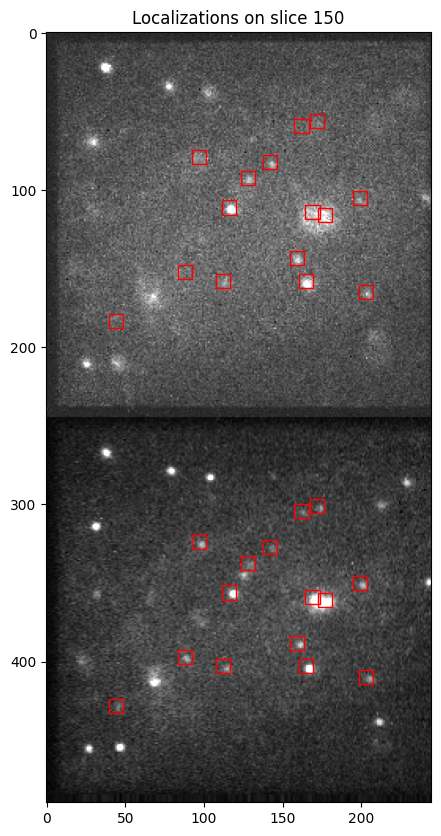

In [59]:
# Visulaize the biplane image with the locations and dublicated localizations on the bottom
visualize_localizations_on_slice(image_stack, localizations_df, slice_index=150)


In [5]:
def get_slices_with_localizations(localizations_filepath):
    """
    Returns a list of slices (T indices) that have localizations.

    Parameters:
    - localizations_filepath: Path to the .h5r localizations file.
    """
    
    # Load the localizations using the provided function
    localizations_df = h5r_to_df(localizations_filepath)
    
    # Get unique slices that have localizations
    slices_with_localizations = localizations_df['tIndex'].unique()
    
    return slices_with_localizations

def display_sample_localizations(localizations_filepath, num_samples=5):
    """
    Display a few sample localizations from the data.

    Parameters:
    - localizations_filepath: Path to the .h5r localizations file.
    - num_samples: Number of sample localizations to display.
    """
    
    # Load the localizations using the provided function
    localizations_df = h5r_to_df(localizations_filepath)
    
    # Sample a few localizations and print them
    samples = localizations_df.sample(min(num_samples, len(localizations_df)))
    print(samples)




In [6]:
# Use the functions
slices_with_localizations = get_slices_with_localizations('/Volumes/T7/compression/Guys_data/localizations/raw/Nir_et_al_thres-12_deb-8_syn-PSF.h5r')
print(f"Slices with localizations: {slices_with_localizations}")

# Display a few sample localizations
#display_sample_localizations('/Volumes/T7/compression/Guys_data/localizations/raw/Nir_et_al_thres-12_deb-8_syn-PSF.h5r')

Slices with localizations: [   51   456   200 ... 65243 65247 65249]
        tIndex  resultCode                               subtractedBackground  \
136558   27582           2  (1714768.9, 4813.345, 15425.114, 219.26334, -2...   
245882   56655           2  (2257812.5, 20181.65, 8113.8345, -452.96402, -...   
18894     4801           2  (1235651.1, 6987.219, 15286.456, 299.77283, -2...   
87382    17438           2  (1697151.4, 7789.415, 8226.285, 299.77283, -22...   
143816   29619           3  (2133468.8, 9585.245, 3728.007, 197.99283, -27...   

        ratio       nchi2  fitResults_A  fitResults_x0  fitResults_y0  \
136558    0.5   93.970352   608808.6875    4951.428711   15567.550781   
245882    0.5  102.629219   464410.5625   20316.074219    8208.877930   
18894     0.5   84.426376   139510.8750    7151.038086   15440.144531   
87382     0.5   89.495537   363739.6250    7914.386719    8338.264648   
143816    0.5   86.525444   817378.0000    9750.075195    3883.997803   

     